# 01. Exploratory Data Analysis: ACN EV Charging Sessions

This notebook explores the raw and cleaned charging session distributions across Caltech, JPL, and Office sites.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import seaborn as sns

from ev_forecasting.config.settings import load_config
from ev_forecasting.data.cleaning import SessionDataCleaner
from ev_forecasting.data.parsing import ACNDataParser

config = load_config("../configs/development.yaml")
parser = ACNDataParser(config)
sessions_df, _ = parser.parse_all_sessions(Path("../data/raw"))
cleaner = SessionDataCleaner(config)
cleaned_df = cleaner.clean_sessions(sessions_df)
cleaned_df.head()

,session_id,site_id,station_id,raw_station_code,start_time,end_time,duration_hours,kwh_delivered,data_points,file_path
0,caltech_2-39-123-23-2018-05-01T17-11-32-081386,caltech,caltech_123,123,2018-05-01 17:11:32+00:00,2018-05-01 20:10:03+00:00,2.975278,7.082071,2807,..\data\raw\caltech\California_Garage_01\2-39-...
1,caltech_2-39-123-23-2018-05-01T20-12-26-312220,caltech,caltech_123,123,2018-05-01 20:12:26+00:00,2018-05-01 23:56:30+00:00,3.734444,6.494604,3493,..\data\raw\caltech\California_Garage_01\2-39-...
2,caltech_2-39-123-23-2018-05-02T13-25-55-840259,caltech,caltech_123,123,2018-05-02 13:25:59+00:00,2018-05-02 14:36:44+00:00,1.179167,4.091142,1078,..\data\raw\caltech\California_Garage_01\2-39-...
3,caltech_2-39-123-23-2018-05-02T15-15-17-269387,caltech,caltech_123,123,2018-05-02 15:15:17+00:00,2018-05-02 18:13:44+00:00,2.974167,11.521205,2782,..\data\raw\caltech\California_Garage_01\2-39-...
4,caltech_2-39-123-23-2018-05-02T18-23-24-918058,caltech,caltech_123,123,2018-05-02 18:23:36+00:00,2018-05-03 05:07:41+00:00,10.734722,2.031229,10068,..\data\raw\caltech\California_Garage_01\2-39-...


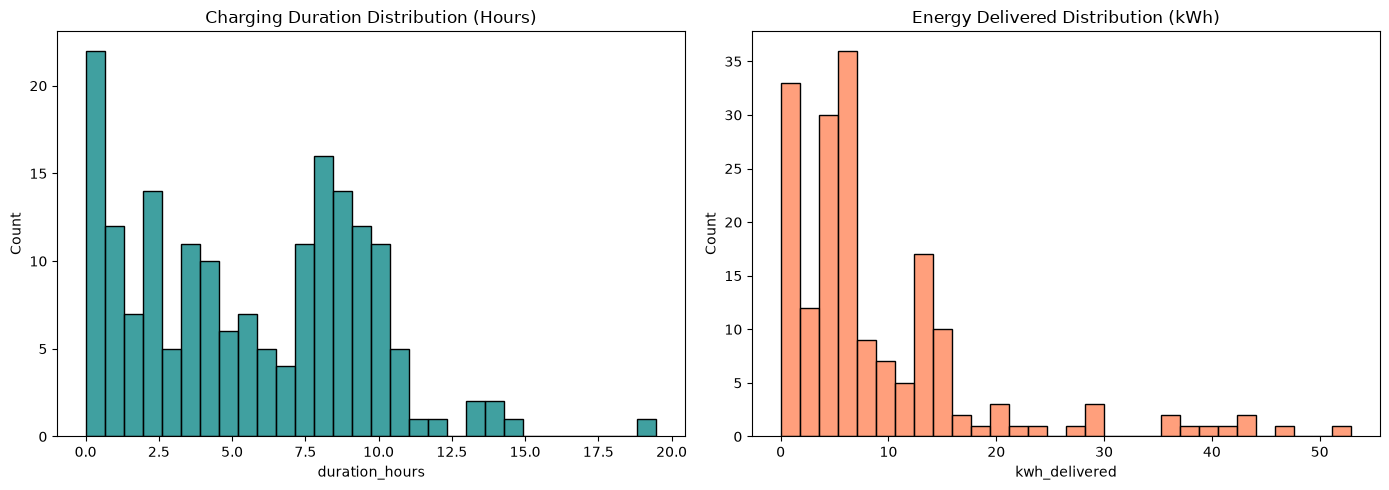

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(cleaned_df["duration_hours"], bins=30, ax=ax1, color="teal")
ax1.set_title("Charging Duration Distribution (Hours)")

sns.histplot(cleaned_df["kwh_delivered"], bins=30, ax=ax2, color="coral")
ax2.set_title("Energy Delivered Distribution (kWh)")
plt.tight_layout()
plt.show()